# Practical Workshop 3 — Initialisation and Regularisation

This notebook works through the initialisation schemes and regularisation techniques you reach for when training neural networks. For each one we do two things: introduce the PyTorch API and use it, then run a short experiment that shows the effect it has.

- **Part A — Initialisation:** LeCun, Xavier/Glorot, He/Kaiming.
- **Part B — Regularisation:** weight decay, batch norm, layer norm, dropout, early stopping.

## Part 0 — Setup

In [1]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", device)

C_GOOD = "#2e8b57"
C_BAD  = "#c0504d"
C_BLUE = "#1f6fb2"
C_GREY = "#8a8a8a"

PyTorch 2.5.1 | device: cpu


/home/luca/miniconda3/envs/kunming-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /opt/conda/conda-bld/pytorch_1729647429097/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


---
# Part A — Initialisation

An initialisation keeps the variance of the activations roughly constant as the signal flows through the layers. To see what a scheme does, we push a random signal through a deep network and record the standard deviation of the activations after each layer. A flat line means the variance is being preserved.

In [59]:
def activation_std_by_depth(activation, init_fn, depth=30, width=256, n_samples=1024, seed=0):
    generator = torch.Generator().manual_seed(seed)

    layers = []
    for _ in range(depth):
        layer = nn.Linear(width, width)
        init_fn(layer)
        layers.append(layer)
        layers.append(activation())

    net = nn.Sequential(*layers)

    h = torch.randn(n_samples, width, generator=generator)
    stds = [h.std().item()]

    with torch.no_grad():
        for module in net:
            h = module(h)
            if isinstance(module, (nn.ReLU, nn.Tanh, nn.SELU)):
                stds.append(h.std().item())

    return stds

## A.1 — LeCun initialisation

There is no `nn.init.lecun_` helper in PyTorch. LeCun simply sets the weight variance to `1 / n`, where `n` is the number of inputs to the layer, so we set the standard deviation directly.

In [60]:
def lecun_(layer):
    n = layer.weight.size(1) # number of inputs to the layer

    nn.init.normal_(layer.weight, std=math.sqrt(1.0 / n))
    nn.init.zeros_(layer.bias)


# Apply it to a single layer and compare the result against the 1/sqrt(n) target
layer = nn.Linear(128, 64)
lecun_(layer)

target_std   = math.sqrt(1 / 128)
realised_std = layer.weight.std().item()

print(f"n = 128  ->  target std {target_std:.4f}  |  realised std {realised_std:.4f}")

n = 128  ->  target std 0.0884  |  realised std 0.0894


LeCun enforces only the forward condition, so it preserves variance when the activation is roughly linear near zero. Below, we show how this works with the `SELU` non-linearity, where the activation std stays almost constant at 1.0 through 30 layers. However, with `tanh`, the forward-only rule slowly under-supplies the signal and it decays with depth.

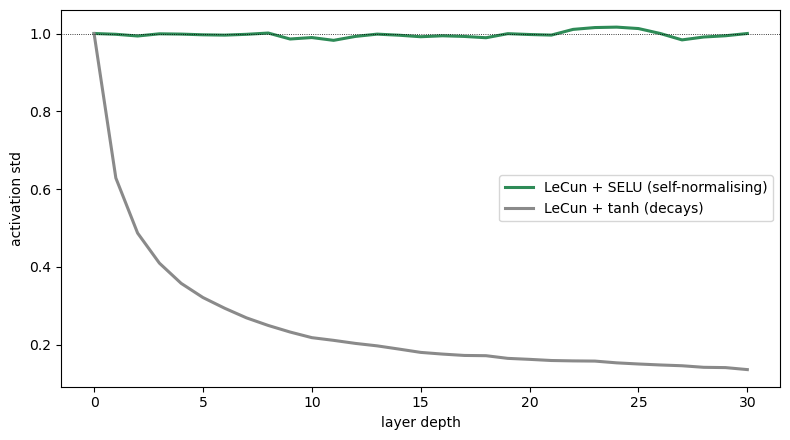

In [61]:
lecun_selu = activation_std_by_depth(nn.SELU, lecun_)
lecun_tanh = activation_std_by_depth(nn.Tanh, lecun_)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(lecun_selu, color=C_GOOD, linewidth=2.2, label="LeCun + SELU (self-normalising)")
ax.plot(lecun_tanh, color=C_GREY, linewidth=2.2, label="LeCun + tanh (decays)")
ax.axhline(1.0, color="black", linewidth=0.6, linestyle=":")

ax.set_xlabel("layer depth")
ax.set_ylabel("activation std")

ax.legend()

plt.tight_layout()
plt.show()

## A.2 — Xavier / Glorot initialisation

Xavier sets the weight variance to `2 / (n + m)`, where `n` and `m` are the number of inputs and outputs of the layer, so it balances the forward and backward passes rather than just the forward one. In PyTorch you call `nn.init.xavier_uniform_` (or `xavier_normal_`) and pass a **gain**.

Every activation changes the scale of the signal passing through it. `tanh` compresses its inputs, so the signal coming out is a little smaller than the signal going in. The **gain** is a single multiplier on the standard deviation that compensates for this, keeping the variance preserved after the activation rather than before it. You match the gain to the activation that follows the layer, and `nn.init.calculate_gain` returns the right value for the common ones.

In [62]:
# calculate_gain returns the multiplier appropriate for each activation
for name in ["linear", "tanh", "relu"]:
    print(f"{name:8s} gain = {nn.init.calculate_gain(name):.4f}")

linear   gain = 1.0000
tanh     gain = 1.6667
relu     gain = 1.4142


In [63]:
def xavier_tanh_(layer):
    gain = nn.init.calculate_gain("tanh")             # 5/3, to match the tanh that follows

    nn.init.xavier_uniform_(layer.weight, gain=gain)
    nn.init.zeros_(layer.bias)

On a deep `tanh` network Xavier holds the activation std roughly constant, while LeCun on the same network drifts downward. Xavier accounts for both passes, which is what a symmetric activation needs.

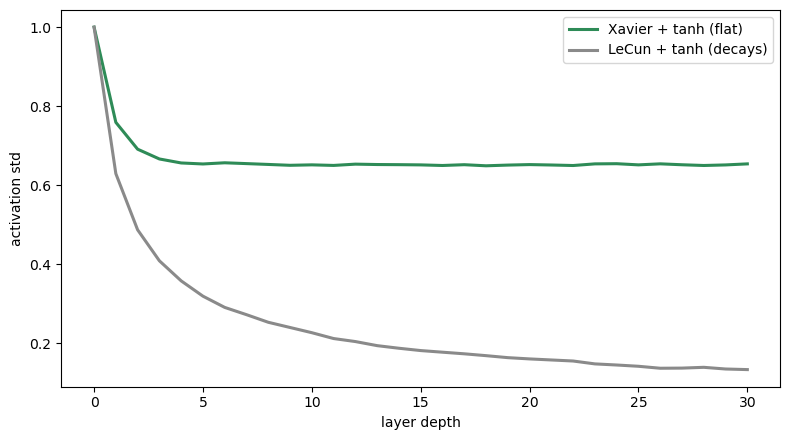

In [64]:
xavier_tanh = activation_std_by_depth(nn.Tanh, xavier_tanh_)
lecun_tanh  = activation_std_by_depth(nn.Tanh, lecun_)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(xavier_tanh, color=C_GOOD, linewidth=2.2, label="Xavier + tanh (flat)")
ax.plot(lecun_tanh,  color=C_GREY, linewidth=2.2, label="LeCun + tanh (decays)")

ax.set_xlabel("layer depth")
ax.set_ylabel("activation std")

ax.legend()

plt.tight_layout()
plt.show()

## A.3 — He / Kaiming initialisation

He sets the weight variance to `2 / n`, double the LeCun value. In PyTorch you call `nn.init.kaiming_normal_` and pass the activation as `nonlinearity`. This is the right default for the whole ReLU family (ReLU, LeakyReLU, GELU).

In [65]:
def he_(layer):
    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
    nn.init.zeros_(layer.bias)


# Apply it to a single layer and compare the result against the sqrt(2/n) target
layer = nn.Linear(128, 64)
he_(layer)

target_std   = math.sqrt(2 / 128)
realised_std = layer.weight.std().item()

print(f"n = 128  ->  target std {target_std:.4f}  |  realised std {realised_std:.4f}")

n = 128  ->  target std 0.1250  |  realised std 0.1255


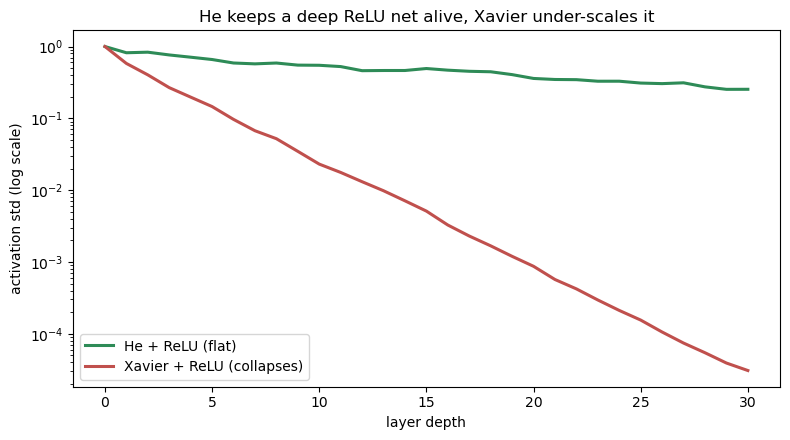

In [66]:
def xavier_linear_(layer):
    # Xavier with gain = 1, to simulate a linear activation
    nn.init.xavier_uniform_(layer.weight, gain=1.0)
    nn.init.zeros_(layer.bias)


he_relu     = activation_std_by_depth(nn.ReLU, he_)
xavier_relu = activation_std_by_depth(nn.ReLU, xavier_linear_)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(he_relu,     color=C_GOOD, linewidth=2.2, label="He + ReLU (flat)")
ax.plot(xavier_relu, color=C_BAD,  linewidth=2.2, label="Xavier + ReLU (collapses)")
ax.set_yscale("log")

ax.set_xlabel("layer depth")
ax.set_ylabel("activation std (log scale)")
ax.set_title("He keeps a deep ReLU net alive, Xavier under-scales it")

ax.legend()

plt.tight_layout()
plt.show()

The factor of 2 exists to cancel the half of the inputs that ReLU sets to zero. With it, a deep ReLU net holds its variance. Using Xavier (built for tanh) on the same ReLU net under-scales every layer, so the signal collapses by orders of magnitude over 30 layers.

## A.4 — How do these initialisations impact training?

Let's fit a noisy sine curve with a 20-layer ReLU network and only change the initialisation. We will compare the He/Kaiming intialisation, with initialising the weights with a standard normal distribution with a standard deviation which is too small, and one that is too large. Hopefully, we will see the effect of divergence and vanishing signals. We keep the architecture the same, the same optimiser, and the same data.

In [67]:
torch.manual_seed(0)

X = torch.linspace(-3, 3, 256).unsqueeze(1)
y = torch.sin(2 * X) + 0.1 * torch.randn_like(X)


def deep_relu_net(depth=20, width=128):
    layers = [nn.Linear(1, width), nn.ReLU()]

    for _ in range(depth - 2):
        layers.append(nn.Linear(width, width))
        layers.append(nn.ReLU())

    layers.append(nn.Linear(width, 1))

    return nn.Sequential(*layers)


def init_normal(model, std):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.normal_(layer.weight, std=std)
            nn.init.zeros_(layer.bias)

    return model


def init_he(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            he_(layer)

    return model

In [68]:
def train(model, X, y, n_epochs, optimiser, loss_fn):
    losses = []

    for epoch in range(n_epochs):
        y_hat = model(X)               # 1. forward
        loss = loss_fn(y_hat, y)       # 2. loss
        optimiser.zero_grad()          # 3. zero
        loss.backward()                # 4. backward
        optimiser.step()               # 5. step
        losses.append(loss.item())

    return losses


def diverged(losses, threshold=1e3):
    arr = np.array(losses)
    return np.any(~np.isfinite(arr)) or arr[-1] > threshold

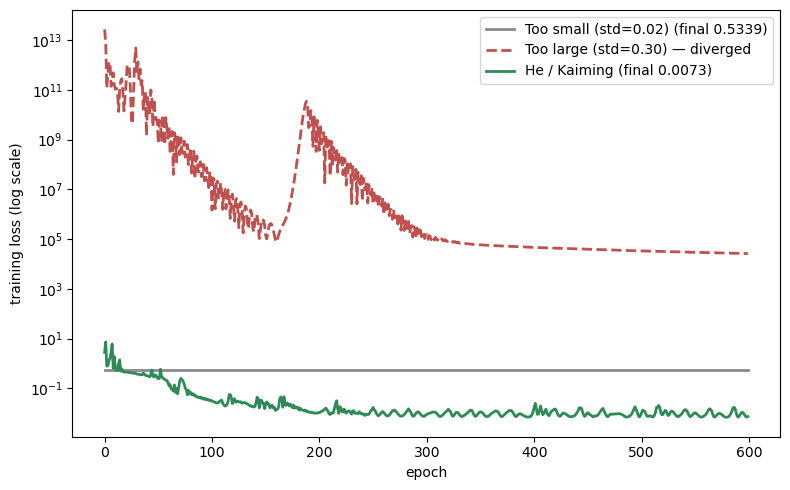

In [69]:
configs = [
    ("Too small (std=0.02)", lambda m: init_normal(m, 0.02), C_GREY),
    ("Too large (std=0.30)", lambda m: init_normal(m, 0.30), C_BAD),
    ("He / Kaiming",         init_he,                           C_GOOD),
]

fig, ax = plt.subplots(figsize=(8, 5))

for label, init_fn, colour in configs:
    torch.manual_seed(1)

    model     = init_fn(deep_relu_net())
    optimiser = torch.optim.Adam(model.parameters(), lr=3e-3)
    losses    = train(model, X, y, n_epochs=600, optimiser=optimiser, loss_fn=nn.MSELoss())

    if diverged(losses):
        ax.plot(losses, color=colour, linewidth=2, linestyle="--", label=f"{label} — diverged")
    else:
        ax.plot(losses, color=colour, linewidth=2, label=f"{label} (final {losses[-1]:.4f})")

ax.set_yscale("log")

ax.set_xlabel("epoch")
ax.set_ylabel("training loss (log scale)")

ax.legend()

plt.tight_layout()
plt.show()

Exactly as we had predicted! When the weights are initialised with a too low std normal distribution, the signal vanishes and the model cannot learn. The opposite is true when we have the std too large. The He/Kaiming initialisation of the std is the only one that has the right balance to not cause the signal to vanish or explode.

---
# Part B — Regularisation

In this section we look at each regularisation technique from the slides in turn. Each one needs a model that overfits before its effect is visible, so we first construct a dataset and a network that overfit badly on purpose.

The dataset is designed so that overfitting is easy. Each input has 100 features, but the binary label depends on only the first 5 of them; the remaining 95 are random noise with no relationship to the label. We draw 1,000 examples for validation but only 100 for training. With so few training points and a high-capacity network, the model can fit the training set perfectly by memorising patterns in the noise features, which then fail to generalise to the validation set.

In [70]:
def generate_dataset(n_samples, generator, n_features=100, n_informative=5, w_true=None):
    X = torch.randn(n_samples, n_features, generator=generator)

    logits = (X[:, :n_informative] @ w_true).squeeze()
    y      = (logits > logits.median()).long()

    return X, y

In [71]:
generator = torch.Generator().manual_seed(0)

n_samples_train = 100
n_samples_val   = 1000
n_features      = 100
n_informative   = 5
w_true          = torch.randn(n_informative, 1, generator=generator)

X_train, y_train = generate_dataset(n_samples_train,  generator, n_features, n_informative, w_true)
X_val,   y_val   = generate_dataset(n_samples_val,   generator, n_features, n_informative, w_true)

print("train:", tuple(X_train.shape), "| val:", tuple(X_val.shape))
print("informative features:", n_informative, "of", n_features)

train: (100, 100) | val: (1000, 100)
informative features: 5 of 100


In [72]:
def build_mlp(p_drop=0.0, use_bn=False, in_dim=100, width=256, depth=2, out_dim=2):
    """Build an MLP with `depth` hidden layers, optionally with BatchNorm and/or Dropout.
    """
    widths = [in_dim] + [width] * depth
    layers = []

    for in_features, out_features in zip(widths, widths[1:]):
        layers.append(nn.Linear(in_features, out_features))
        if use_bn:
            layers.append(nn.BatchNorm1d(out_features))
        layers.append(nn.ReLU())
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))

    layers.append(nn.Linear(width, out_dim))
    return nn.Sequential(*layers)

In [73]:
def train_classifier(model, optimiser, n_epochs=400):
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses   = []

    for epoch in range(n_epochs):
        model.train()

        optimiser.zero_grad()
        loss = loss_fn(model(X_train), y_train)
        loss.backward()
        optimiser.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val)

        val_losses.append(val_loss.item())

    return train_losses, val_losses


@torch.no_grad()
def accuracy(model, X, y):
    model.eval()
    return (model(X).argmax(1) == y).float().mean().item()

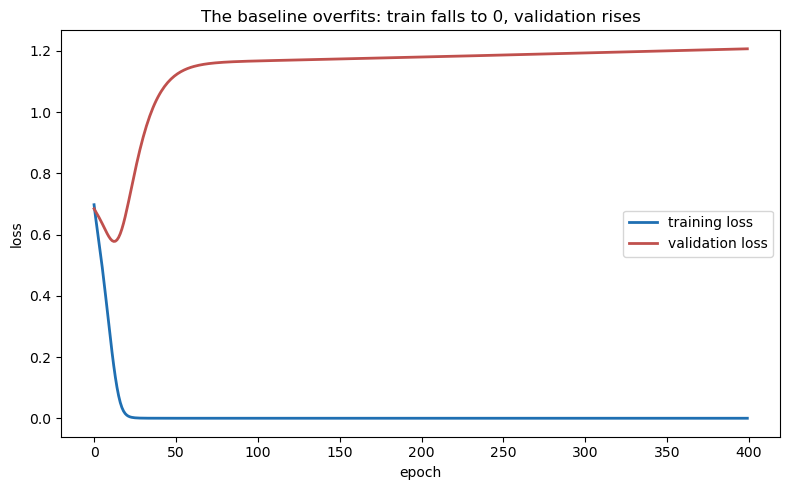

train accuracy 1.000  |  val accuracy 0.714


In [74]:
torch.manual_seed(1)

baseline_model = build_mlp()
optimiser      = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

train_losses, val_losses = train_classifier(baseline_model, optimiser)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_losses, color=C_BLUE, linewidth=2, label="training loss")
ax.plot(val_losses,   color=C_BAD,  linewidth=2, label="validation loss")

ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("The baseline overfits: train falls to 0, validation rises")

ax.legend()

plt.tight_layout()
plt.show()

print(f"train accuracy {accuracy(baseline_model, X_train, y_train):.3f}  |  val accuracy {accuracy(baseline_model, X_val, y_val):.3f}")

Train accuracy is 100%, showing how our model has completely memorised the training dataset. Instead, validation loss climbs after an early minimum, showcasing strong signs of overfitting.

## B.1 — Weight decay

 Weight decay is added through a single argument on the optimiser and requires no change to the model. With plain SGD it is equivalent to adding an L2 penalty to the loss, since both shrink every weight by a factor of `(1 − ηλ)` on each step. This equivalence breaks down with Adam, where the L2 penalty interacts with the per-parameter adaptive step sizes and is no longer applied uniformly across weights. The `AdamW` optimiser fixes this by decoupling the decay from the gradient update and applying it directly to the weights, so prefer `AdamW` over `Adam` whenever you use weight decay.

In [75]:
# The only change is the weight_decay argument
model = build_mlp()

opt_sgd   = torch.optim.SGD(model.parameters(),   lr=0.05, momentum=0.9, weight_decay=0.05)
opt_adamw = torch.optim.AdamW(model.parameters(), lr=1e-3,               weight_decay=1e-2)

print("SGD weight_decay:", opt_sgd.defaults["weight_decay"])
print("AdamW weight_decay:", opt_adamw.defaults["weight_decay"])

SGD weight_decay: 0.05
AdamW weight_decay: 0.01


In [76]:
def train_sgd(model, weight_decay, n_epochs=800, lr=0.05):
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    return train_classifier(model, optimiser, n_epochs)


torch.manual_seed(1)
model_plain = build_mlp()
_, val_plain = train_sgd(model_plain, weight_decay=0.0)

torch.manual_seed(1)
model_decay = build_mlp()
_, val_decay = train_sgd(model_decay, weight_decay=0.05)


def collect_all_weights(model):
    weights = [p.detach().flatten() for name, p in model.named_parameters() if "weight" in name]
    return torch.cat(weights)

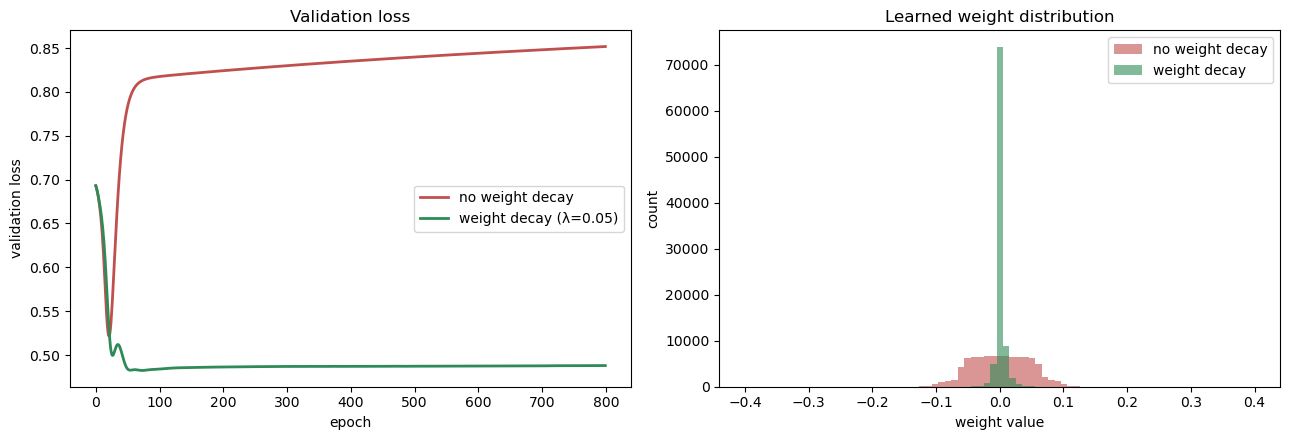

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: validation loss with and without decay
axes[0].plot(val_plain, color=C_BAD,  linewidth=2, label="no weight decay")
axes[0].plot(val_decay, color=C_GOOD, linewidth=2, label="weight decay (λ=0.05)")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation loss")
axes[0].set_title("Validation loss")

axes[0].legend()

# Right: the learned weight distribution
bins = np.linspace(-0.4, 0.4, 80)

axes[1].hist(collect_all_weights(model_plain).numpy(), bins=bins, alpha=0.6, color=C_BAD,  label="no weight decay")
axes[1].hist(collect_all_weights(model_decay).numpy(), bins=bins, alpha=0.6, color=C_GOOD, label="weight decay")

axes[1].set_xlabel("weight value")
axes[1].set_ylabel("count")
axes[1].set_title("Learned weight distribution")

axes[1].legend()

plt.tight_layout()
plt.show()

Two key observations. Firstly, our validation loss curve now looks healthy, showing almost monotone decrease as a function of epoch. Secondly, adding weight decay has shrinked the magnitude of our model parameters, as seen by the spread of the histogram of weight values shrinking around 0.

## B.2 — Batch normalisation

Batch normalisation standardises the inputs to a layer using the mean and variance of the current batch, which steadies the scale of activations as they pass through the network and makes training faster and more stable.

Add an `nn.BatchNorm1d(features)` after a linear layer, or `nn.BatchNorm2d(channels)` after a convolutional layer. The layer holds two learnable parameters per feature, a scale and a shift, which are trained alongside the rest of the network. Its behaviour also differs between the two modes. In `train()` mode it normalises each batch using that batch's own statistics, while in `eval()` mode it uses the running averages of the mean and variance accumulated during training. You must therefore call `model.eval()` before validation or testing, otherwise the layer will normalise using the test batch and the results will depend on how the test data happens to be batched.

In [81]:
# A hidden block places BatchNorm between the linear layer and the activation.
bn_block   = nn.Sequential(nn.Linear(20, 64),
                           nn.BatchNorm1d(64),
                           nn.ReLU())
                           
print(bn_block)

# BatchNorm's two learnable parameters: 'weight' is the scale γ, 'bias' is the shift β.
batchnorm_layer = next(layer for layer in bn_block if isinstance(layer, nn.BatchNorm1d))
parameter_names = [name for name, _ in batchnorm_layer.named_parameters()]
print("\nLearnable parameters in the BatchNorm layer:", parameter_names)

Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
)

Learnable parameters in the BatchNorm layer: ['weight', 'bias']


This demo uses a separate dataset because it asks a different question: not whether the model generalises, but whether a deep network can train at all at a high learning rate. For this, we need an easily learnable target, so any failure to reduce the loss points to the optimisation rather than the data.

There are 512 examples with 20 standard-normal features each. The label depends on only the first 3: we sum them, add a little noise, and assign class 1 when the result is positive. The other 17 features are irrelevant. The signal is simple and examples are plentiful, so a well-behaved model fits it easily, and a network that stalls is being held back by optimisation, not by the data.

In [82]:
torch.manual_seed(0)

X_deep = torch.randn(512, 20)
y_deep = (X_deep[:, :3].sum(1) + 0.3 * torch.randn(512) > 0).long()

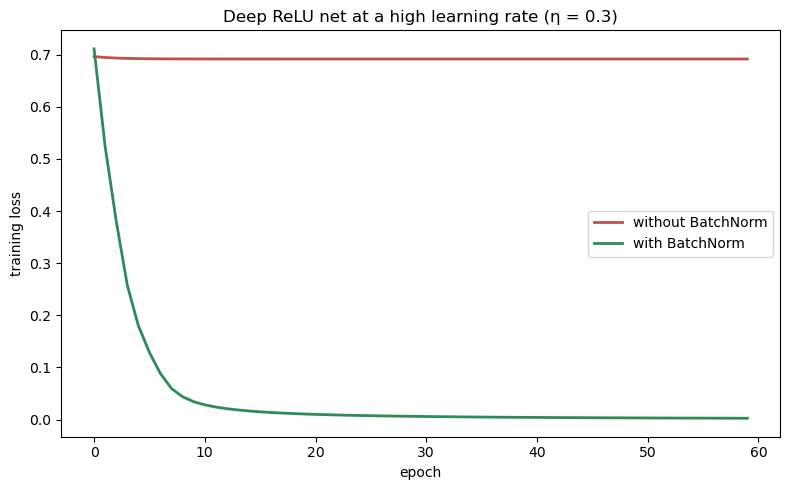

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))

for use_bn, colour, label in [(False, C_BAD, "without BatchNorm"), (True, C_GOOD, "with BatchNorm")]:
    torch.manual_seed(1)

    model     = build_mlp(use_bn=use_bn, in_dim=20, width=64, depth=8, out_dim=2)
    optimiser = torch.optim.SGD(model.parameters(), lr=0.3)
    losses    = train(model, X_deep, y_deep, n_epochs=60,
                      optimiser=optimiser, loss_fn=nn.CrossEntropyLoss())

    ax.plot(losses, color=colour, linewidth=2, label=label)

ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("Deep ReLU net at a high learning rate (η = 0.3)")
ax.legend()

plt.tight_layout()
plt.show()

BatchNorm mainly helps optimisation rather than overfitting. By smoothing the loss surface, it lets you train deep networks at learning rates that would otherwise stall them. We see this very clearly in the figure above.

## B.3 — Layer normalisation

Layer normalisation standardises each sample using the mean and variance of its own features, rather than statistics pooled across the batch. Because the statistics come from within the sample, it does not depend on the batch at all.

Add an `nn.LayerNorm(features)` after a linear layer, passing the number of features it should normalise over. Like BatchNorm, it has a learnable scale and shift per feature. Since the statistics are computed per sample, the layer behaves identically in `train()` and `eval()` mode: there are no running averages to maintain, so the train-versus-eval distinction that BatchNorm requires does not arise here.

In [86]:
ln_block = nn.Sequential(nn.Linear(20, 64),
                         nn.LayerNorm(64),
                         nn.ReLU())

print(ln_block)

# LayerNorm's two learnable parameters: 'weight' is the scale γ, 'bias' is the shift β.
layer_norm_layer = next(layer for layer in ln_block if isinstance(layer, nn.LayerNorm))
parameter_names = [name for name, _ in layer_norm_layer.named_parameters()]
print("\nLearnable parameters in the LayerNorm layer:", parameter_names)

Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
)

Learnable parameters in the LayerNorm layer: ['weight', 'bias']


We see how that since LayerNorm is independent of batch size, it can function even when `batch size = 1`. This is not the case for BatchNorm.

To showcase this, we generate a single sample, i.e., a dataset of `batch size = 1`.

In [87]:
x_single = torch.randn(1, 10)

batch_norm = nn.BatchNorm1d(10)
batch_norm.train()

try:
    batch_norm(x_single)
    print("BatchNorm @ batch size 1: ok")
except ValueError as error:
    print("BatchNorm @ batch size 1: FAILS.", str(error).split(".")[0])

layer_norm = nn.LayerNorm(10)
out = layer_norm(x_single)

print(f"LayerNorm @ batch size 1: ok. mean {out.mean():.2e}, std {out.std():.3f}")

BatchNorm @ batch size 1: FAILS. Expected more than 1 value per channel when training, got input size torch
LayerNorm @ batch size 1: ok. mean -3.58e-08, std 1.054


## B.4 — Dropout

Dropout randomly sets a fraction of a layer's activations to zero on each training step, which stops the network from relying too heavily on any single unit and forces it to spread its representation across many. The fraction zeroed is set by the probability `p`.

Insert `nn.Dropout(p)` after an activation. Like BatchNorm, it is mode-aware: in `train()` mode it drops activations, and in `eval()` mode it does nothing, so the full network is used at test time. To keep the expected size of the activations the same in both modes, PyTorch divides the surviving activations by `1 - p` during training, so you do not need to rescale anything yourself.

In [ ]:
dropout_block = nn.Sequential(nn.Linear(20, 64),
                              nn.ReLU(),
                              nn.Dropout(0.3))

print(dropout_block)

Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
)


## B.5 — Early stopping

Early stopping ends training once validation performance stops improving, rather than running for a fixed number of epochs. This keeps the model from continuing into the regime where it fits the training set ever more closely while generalising worse.

Early stopping is not a layer but a pattern in the training loop. After each epoch, evaluate the validation loss and keep a copy of the weights whenever it reaches a new best. If the validation loss fails to improve for a set number of epochs, called the patience, stop training and restore the saved best weights. Two details are easy to get wrong. Firstly, save the weights at their best point rather than at the end. Secondly, load them back before using the model, since the final weights are already past the point of best generalisation.

In [97]:
def train_early_stopping(model, optimiser, patience=20, max_epochs=400):
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses   = []

    best_val   = float("inf")
    best_epoch = 0
    best_state = None
    wait       = 0

    for epoch in range(max_epochs):
        model.train()

        optimiser.zero_grad()
        loss = loss_fn(model(X_train), y_train)
        loss.backward()
        optimiser.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val).item()

        val_losses.append(val_loss)

        if val_loss < best_val - 1e-4:               # improved: remember these weights
            best_val   = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait       = 0
        else:                                        # no improvement
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)                # restore the best, not the last

    return train_losses, val_losses, best_epoch

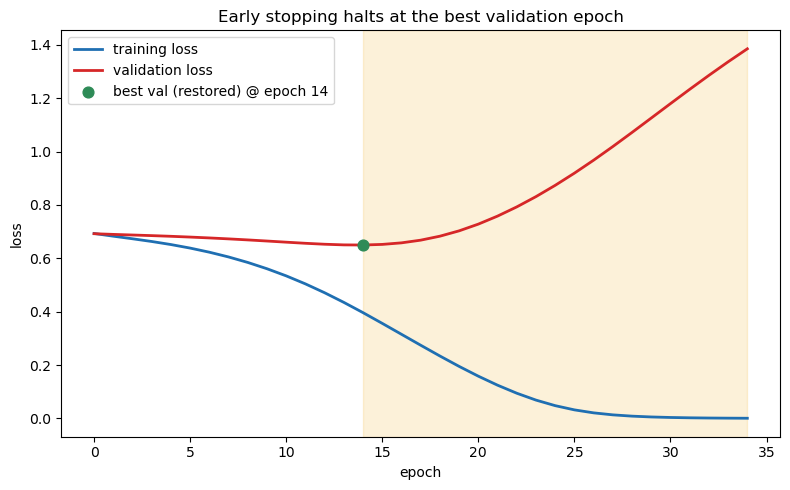

stopped at epoch 34, restored weights from epoch 14


In [98]:
torch.manual_seed(1)

model     = build_mlp()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses, best_epoch = train_early_stopping(model, optimiser)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_losses, color=C_BLUE, linewidth=2, label="training loss")
ax.plot(val_losses,   color=C_BAD,  linewidth=2, label="validation loss")

ax.axvspan(best_epoch, len(val_losses) - 1, color="#f0a500", alpha=0.15)
ax.scatter([best_epoch], [val_losses[best_epoch]], color=C_GOOD, s=60, zorder=5,
           label=f"best val (restored) @ epoch {best_epoch}")

ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Early stopping halts at the best validation epoch")

ax.legend()

plt.tight_layout()
plt.show()

print(f"stopped at epoch {len(val_losses) - 1}, restored weights from epoch {best_epoch}")

Using early stopping, our model would have stopped training after 14 epochs.

## B.6 — Putting it together

These techniques are not alternatives to pick between. A typical model uses several at once. Sensible starting points for a new network are:

- **Initialisation:** He for ReLU or GELU layers (PyTorch's default is already close).
- **Normalisation:** BatchNorm for convolutional networks, LayerNorm for Transformers.
- **Optimiser:** AdamW at a learning rate of about `1e-3`, with a small weight decay such as `1e-2`.
- **Dropout:** between 0.1 and 0.3, added only if the model still overfits.
- **Early stopping:** on validation loss, restoring the best weights.

When a model does overfit, work through the fixes in order of cost and effectiveness, cheapest and most reliable first:

1. **Add more data.** The most reliable fix whenever it is feasible.
2. **Early stopping.** Essentially free, and restores the best weights.
3. **Weight decay.** Use AdamW with a small `λ`, around `1e-2`.
4. **Dropout.** Start at 0.1 to 0.3 and raise it if overfitting persists.
5. **Reduce capacity.** Use fewer or narrower layers.


### Next: Workshop 4 — Convolutional Neural Networks

 Convolution as a translation-equivariant operation. We will build a small CNN and compare it to a classic neural network. Then will introduce the UNet.